In [358]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Lambda
import os
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt

In [4]:
def vae_loss_function(x_hat, x, mean, logvar):
    recon_term = F.binary_cross_entropy(x_hat, x, reduction='sum') # *negative* log-likelihood
    KL_term = - 0.5 * (1+logvar-mean.pow(2)-logvar.exp()).sum() # *negative* KL term
    return recon_term + KL_term # negative of function, cuz we minimize, not maximize

In [5]:
PATH = os.getcwd()

flatten = Lambda(lambda x: x.view(-1))

transform = Compose([
    ToTensor(),
    flatten
])

mnist_train = MNIST(root=PATH, download=True, train=True, transform=transform)
mnist_test = MNIST(root=PATH, download=True, train=False, transform=transform)
train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=True)

## Adding Latents

In [31]:
class VAEEncoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_latent):
        super().__init__()
        self.n_latent = n_latent
        self.l1 = nn.Linear(n_in, n_hidden)
        self.mean = nn.Linear(n_hidden, n_latent)
        self.log_var = nn.Linear(n_hidden, n_latent)
        self.act = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        x = self.act(self.l1(x))
        mean = self.mean(x)
        log_var = self.log_var(x)
        z = mean + log_var.exp().sqrt() * torch.randn(self.n_latent)
        return z, mean, log_var

class VAEDecoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.n_in = n_in
        self.l1 = nn.Linear(n_in, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_hidden)
        self.l3 = nn.Linear(n_hidden, n_out)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, z):
        assert z.size(-1) == self.n_in
        z = self.act(self.l1(z))
        z = self.act(self.l2(z))
        z = torch.sigmoid(self.l3(z))
        return z

class cVAE(nn.Module):
    def __init__(self, n_in, n_out, n_hidden, n_latent):
        super().__init__()
        self.n_in = n_in
        self.embed_label = nn.Embedding(10, n_latent)
        self.encode = VAEEncoder(n_in=n_in, n_hidden=n_hidden, n_latent=n_latent)
        self.decode = VAEDecoder(n_in=n_latent, n_hidden=n_hidden, n_out=n_out)
        
    def forward(self, x, labels):
        assert x.size(-1) == self.n_in
        z, mean, logvar = self.encode(x)
        z = z + self.embed_label(labels) # try just adding
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [33]:
model = cVAE(n_in=784, n_out=784, n_hidden=400, n_latent=10)
opt = AdamW(model.parameters(), lr=1e-3)
model.train()
#torch.manual_seed(42)
N_EPOCHS=10

for _ in range(N_EPOCHS):
    for i, [imgs, labels] in enumerate(train_dataloader):
        opt.zero_grad()
        
        x_hat, mean, logvar = model(imgs, labels)
        loss = vae_loss_function(x_hat, imgs, mean, logvar)
        loss.backward()
        opt.step()
        if i % 10 == 0: print(f"{i+1}: {loss.item()/100}")

1: 544.0683984375
11: 266.83693359375
21: 217.1348828125
31: 194.0023828125
41: 194.2127734375
51: 196.40400390625
61: 174.62322265625
71: 183.609765625
81: 178.27451171875
91: 168.1006640625
101: 170.164609375
111: 171.0274609375
121: 161.01052734375
131: 165.46798828125
141: 168.7896875
151: 169.54259765625
161: 152.975830078125
171: 155.98328125
181: 160.38310546875
191: 150.251357421875
201: 151.62994140625
211: 154.341181640625
221: 152.26060546875
231: 143.602802734375
241: 144.6214453125
251: 143.43056640625
261: 140.859365234375
271: 143.8116796875
281: 154.89615234375
291: 148.12568359375
301: 141.083994140625
311: 153.36486328125
321: 152.915380859375
331: 152.1498046875
341: 134.624775390625
351: 138.381337890625
361: 136.841328125
371: 136.330859375
381: 149.021953125
391: 142.2784765625
401: 147.37134765625
411: 143.35666015625
421: 144.7452734375
431: 136.4630859375
441: 146.80779296875
451: 139.652685546875
461: 138.140400390625
471: 140.670673828125
481: 139.3725390625


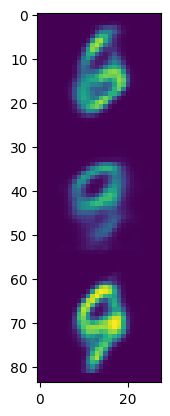

In [163]:
model.eval()
z = torch.randn(10)
ll = model.embed_label(torch.tensor(9))
img = model.decode(z)
img2 = model.decode(ll)
img3 = model.decode(z + ll)
imshow(torch.cat((img, img2, img3)).detach().numpy().reshape((3*28, 28)))

## Concatenating Latents

In [202]:
class VAEEncoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_latent):
        super().__init__()
        self.n_latent = n_latent
        self.l1 = nn.Linear(n_in + n_latent, n_hidden) # concat label embeddings
        self.mean = nn.Linear(n_hidden, n_latent)
        self.log_var = nn.Linear(n_hidden, n_latent)
        self.act = nn.LeakyReLU(0.2)
        
    def forward(self, x, label_embedding):
        x = torch.cat((x, label_embedding), dim=1) # this is very important; hardly works otherwise 
         
        x = self.act(self.l1(x))
        mean = self.mean(x)
        log_var = self.log_var(x)

        z = mean + log_var.exp().sqrt() * torch.randn(self.n_latent)
        return z, mean, log_var

class VAEDecoder(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.n_in = n_in*2
        self.l1 = nn.Linear(n_in*2, n_hidden) # concatenated the input, thus n_in*2 (one for conditioning 10 vector)
        self.l2 = nn.Linear(n_hidden, n_hidden)
        self.l3 = nn.Linear(n_hidden, n_out)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, z):
        assert z.size(-1) == self.n_in
        z = self.act(self.l1(z))
        z = self.act(self.l2(z))
        z = torch.sigmoid(self.l3(z))
        return z

class cVAE(nn.Module):
    def __init__(self, n_in, n_out, n_hidden, n_latent):
        super().__init__()
        self.n_in = n_in
        self.embed_label = nn.Embedding(10, n_latent)
        self.encode = VAEEncoder(n_in=n_in, n_hidden=n_hidden, n_latent=n_latent)
        self.decode = VAEDecoder(n_in=n_latent, n_hidden=n_hidden, n_out=n_out)
        
    def forward(self, x, labels):
        assert x.size(-1) == self.n_in
        label_embedding = self.embed_label(labels)
        z, mean, logvar = self.encode(x, label_embedding)
        z = torch.cat((z, label_embedding), dim=1) # try just adding
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [173]:
model = cVAE(n_in=784, n_out=784, n_hidden=400, n_latent=10)
opt = AdamW(model.parameters(), lr=1e-3)
model.train()
#torch.manual_seed(42)
N_EPOCHS=10

for _ in range(N_EPOCHS):
    for i, [imgs, labels] in enumerate(train_dataloader):
        opt.zero_grad()
        
        x_hat, mean, logvar = model(imgs, labels)
        loss = vae_loss_function(x_hat, imgs, mean, logvar)
        loss.backward()
        opt.step()
        if i % 10 == 0: print(f"{i+1}: {loss.item()/100}")

1: 545.44796875
11: 266.69341796875
21: 231.12478515625
31: 204.60794921875
41: 193.409140625
51: 191.8282421875
61: 175.73783203125
71: 174.5569921875
81: 177.7533203125
91: 180.19107421875
101: 174.33515625
111: 188.50505859375
121: 158.34931640625
131: 168.24103515625
141: 164.6659375
151: 175.540859375
161: 160.315234375
171: 160.73552734375
181: 166.257578125
191: 157.256337890625
201: 164.6346484375
211: 149.53921875
221: 147.780439453125
231: 165.0623828125
241: 151.704755859375
251: 153.520166015625
261: 156.30791015625
271: 147.062734375
281: 153.352626953125
291: 152.067578125
301: 147.45998046875
311: 141.98130859375
321: 136.4678125
331: 142.358447265625
341: 140.20228515625
351: 142.871455078125
361: 133.23484375
371: 145.623837890625
381: 140.222919921875
391: 135.668662109375
401: 136.418701171875
411: 143.697802734375
421: 140.88806640625
431: 144.4063671875
441: 148.6690234375
451: 131.939931640625
461: 139.85140625
471: 141.527548828125
481: 139.575546875
491: 136.140

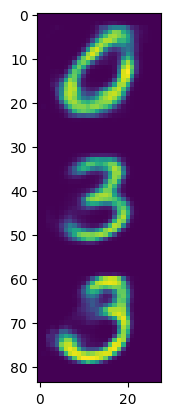

In [324]:
model.eval()
z = torch.randn(10)
ll = model.embed_label(torch.tensor(3))
img = model.decode(torch.cat((z, torch.zeros(10))))
img2 = model.decode(torch.cat((torch.zeros(10), ll)))
img3 = model.decode(torch.cat((z, ll)))
imshow(torch.cat((img, img2, img3)).detach().numpy().reshape((3*28, 28)))

In [360]:
def sample_img(model, z_img, condition):
    model.eval()
    z_cond = model.embed_label(torch.tensor(condition))
    z = torch.cat((z_img, z_cond))
    img = model.decode(z)
    imshow(img.detach().numpy().reshape(28,28))
    plt.show()
    return img

In [365]:
z_img = torch.randn(10)

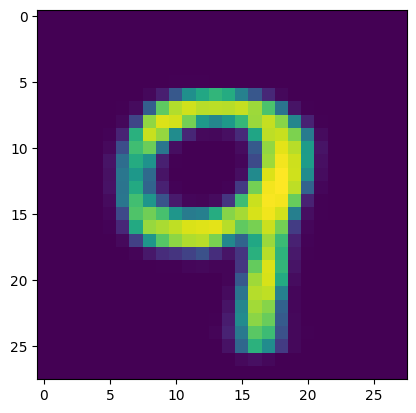

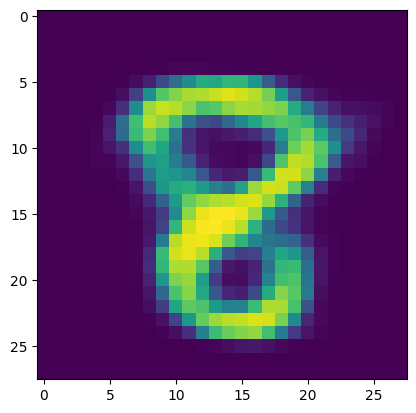

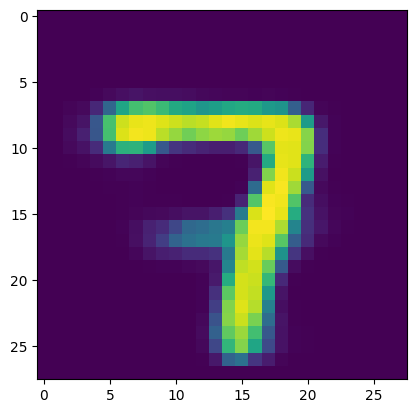

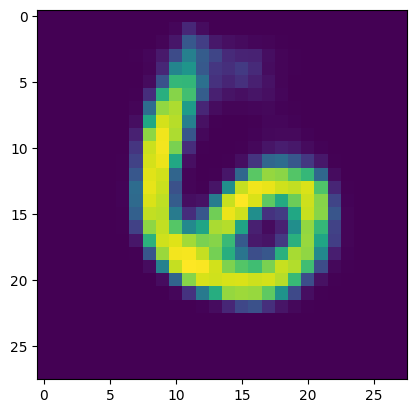

In [386]:
model.eval()

a = sample_img(model, z_img, condition=9)
b = sample_img(model, z_img, condition=8)
a = sample_img(model, z_img, condition=7)
b = sample_img(model, z_img, condition=6)

In [415]:
z_img_1 = torch.randn(10)
z_img_2 = torch.randn(10)
z_img_1, z_img_2

(tensor([-1.2401, -0.6588,  1.3765,  0.0539, -0.2385,  0.7698, -0.7037, -0.4184,
          0.0756, -0.2443]),
 tensor([ 0.6899,  1.5002, -0.5450,  0.5596,  0.6980,  1.3341, -0.2264,  1.1540,
         -0.1148, -0.9376]))

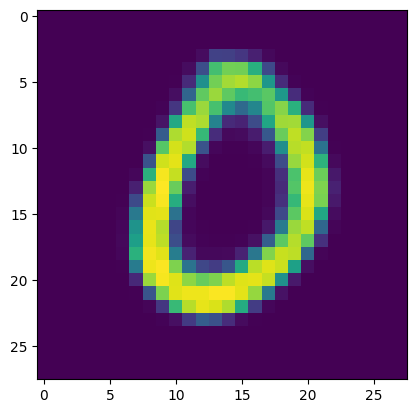

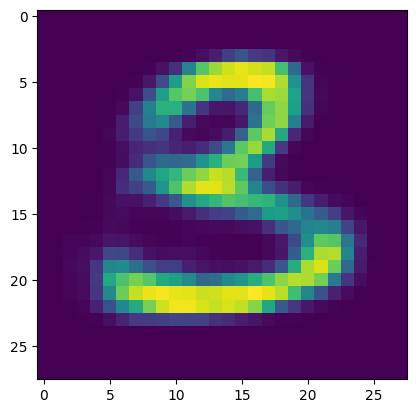

In [417]:
model.eval()

a = sample_img(model, z_img_1, condition=0)
b = sample_img(model, z_img_2, condition=3)